In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import os

#path = '/mnt/d/GoogleDrive/AI_learning/Week1/3_makemore_p2'
file = 'names.txt'
#filepath = os.path.join(path, file)
words = open(file, 'r').read().splitlines()
print(words[:8])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033


In [5]:
chars = sorted(list(set(''.join(words))))
print(chars)
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
block_size = 3  # context length: how many characters do we take to predict next?
X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]    # shift one charater to the left and append the new character

X = torch.tensor(X)
Y = torch.tensor(Y)


emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [4]:
print(X)        # input
print(Y)        # predict

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])
tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])


In [9]:
print(X.shape, X.dtype)
print(Y.shape, Y.dtype)

torch.Size([32, 3]) torch.int64
torch.Size([32]) torch.int64


In [6]:
C = torch.randn((27, 2))        # each character gets mapped to a 2-dimensional vector
print(C[5])

tensor([-1.0048, -1.2532])


In [7]:
print(F.one_hot(torch.tensor([5]), num_classes=27))
F.one_hot(torch.tensor([5]), num_classes=27).float() @ C # F.one_hot(torch.tensor([5]), num_classes=27).dtype = torch.int64, @C directly will cause error 

tensor([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0]])


tensor([[-1.0048, -1.2532]])

In [34]:
C[torch.tensor([5, 6, 7, 7, 7])]    #5th row, 6th row, 7th row, 7th row, 7th row
#C.shape

tensor([[-1.0048, -1.2532],
        [ 0.7773, -0.0935],
        [ 0.4654,  0.3272],
        [ 0.4654,  0.3272],
        [ 0.4654,  0.3272]])

In [9]:
print(C[X])
C[X].shape

tensor([[[ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353]],

        [[ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [-1.0048, -1.2532]],

        [[ 0.5399,  1.2353],
         [-1.0048, -1.2532],
         [ 0.6731, -0.3183]],

        [[-1.0048, -1.2532],
         [ 0.6731, -0.3183],
         [ 0.6731, -0.3183]],

        [[ 0.6731, -0.3183],
         [ 0.6731, -0.3183],
         [-0.1118,  0.9491]],

        [[ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353]],

        [[ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [-0.3338, -0.5433]],

        [[ 0.5399,  1.2353],
         [-0.3338, -0.5433],
         [ 2.6671, -0.5728]],

        [[-0.3338, -0.5433],
         [ 2.6671, -0.5728],
         [ 0.0650, -0.9492]],

        [[ 2.6671, -0.5728],
         [ 0.0650, -0.9492],
         [-0.2378, -0.3145]],

        [[ 0.0650, -0.9492],
         [-0.2378, -0.3145],
         [ 0.0650, -0.9492]],

        [[-0.2378, -0

torch.Size([32, 3, 2])

In [10]:
X[13, 2]

tensor(1)

In [23]:
emb = C[X]
print(emb)
emb.shape

tensor([[[ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353]],

        [[ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [-1.0048, -1.2532]],

        [[ 0.5399,  1.2353],
         [-1.0048, -1.2532],
         [ 0.6731, -0.3183]],

        [[-1.0048, -1.2532],
         [ 0.6731, -0.3183],
         [ 0.6731, -0.3183]],

        [[ 0.6731, -0.3183],
         [ 0.6731, -0.3183],
         [-0.1118,  0.9491]],

        [[ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353]],

        [[ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [-0.3338, -0.5433]],

        [[ 0.5399,  1.2353],
         [-0.3338, -0.5433],
         [ 2.6671, -0.5728]],

        [[-0.3338, -0.5433],
         [ 2.6671, -0.5728],
         [ 0.0650, -0.9492]],

        [[ 2.6671, -0.5728],
         [ 0.0650, -0.9492],
         [-0.2378, -0.3145]],

        [[ 0.0650, -0.9492],
         [-0.2378, -0.3145],
         [ 0.0650, -0.9492]],

        [[-0.2378, -0

torch.Size([32, 3, 2])

In [12]:
#emb[:, 0, :].shape
print(torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1))
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape # flatten the last dimension, e.g., [[a, b], [c, d], [e, f]] --> [a, b, c, d, e, f]

tensor([[ 0.5399,  1.2353,  0.5399,  1.2353,  0.5399,  1.2353],
        [ 0.5399,  1.2353,  0.5399,  1.2353, -1.0048, -1.2532],
        [ 0.5399,  1.2353, -1.0048, -1.2532,  0.6731, -0.3183],
        [-1.0048, -1.2532,  0.6731, -0.3183,  0.6731, -0.3183],
        [ 0.6731, -0.3183,  0.6731, -0.3183, -0.1118,  0.9491],
        [ 0.5399,  1.2353,  0.5399,  1.2353,  0.5399,  1.2353],
        [ 0.5399,  1.2353,  0.5399,  1.2353, -0.3338, -0.5433],
        [ 0.5399,  1.2353, -0.3338, -0.5433,  2.6671, -0.5728],
        [-0.3338, -0.5433,  2.6671, -0.5728,  0.0650, -0.9492],
        [ 2.6671, -0.5728,  0.0650, -0.9492, -0.2378, -0.3145],
        [ 0.0650, -0.9492, -0.2378, -0.3145,  0.0650, -0.9492],
        [-0.2378, -0.3145,  0.0650, -0.9492, -0.1118,  0.9491],
        [ 0.5399,  1.2353,  0.5399,  1.2353,  0.5399,  1.2353],
        [ 0.5399,  1.2353,  0.5399,  1.2353, -0.1118,  0.9491],
        [ 0.5399,  1.2353, -0.1118,  0.9491, -0.2378, -0.3145],
        [-0.1118,  0.9491, -0.2378, -0.3

torch.Size([32, 6])

In [13]:
torch.unbind(emb, dim=1)    # unbind the second dimension, e.g., [[a, b], [c, d], [e, f]] --> [[a, c, e], [b, d, f]]
#torch.unbind(emb, dim=1)[0].shape    
#len(torch.unbind(emb, dim=1))    

(tensor([[ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [-1.0048, -1.2532],
         [ 0.6731, -0.3183],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [-0.3338, -0.5433],
         [ 2.6671, -0.5728],
         [ 0.0650, -0.9492],
         [-0.2378, -0.3145],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [-0.1118,  0.9491],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [ 0.0650, -0.9492],
         [ 1.7210, -0.1297],
         [-0.1118,  0.9491],
         [-0.5011,  1.6339],
         [-1.0048, -1.2532],
         [ 2.6671, -0.5728],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [ 1.7210, -0.1297],
         [-0.3338, -0.5433],
         [-0.5914, -0.5339],
         [ 0.1248, -0.6170]]),
 tensor([[ 0.5399,  1.2353],
         [ 0.5399,  1.2353],
         [-1

In [14]:
torch.cat(torch.unbind(emb, dim=1), 1) # same as torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1), but more general.

tensor([[ 0.5399,  1.2353,  0.5399,  1.2353,  0.5399,  1.2353],
        [ 0.5399,  1.2353,  0.5399,  1.2353, -1.0048, -1.2532],
        [ 0.5399,  1.2353, -1.0048, -1.2532,  0.6731, -0.3183],
        [-1.0048, -1.2532,  0.6731, -0.3183,  0.6731, -0.3183],
        [ 0.6731, -0.3183,  0.6731, -0.3183, -0.1118,  0.9491],
        [ 0.5399,  1.2353,  0.5399,  1.2353,  0.5399,  1.2353],
        [ 0.5399,  1.2353,  0.5399,  1.2353, -0.3338, -0.5433],
        [ 0.5399,  1.2353, -0.3338, -0.5433,  2.6671, -0.5728],
        [-0.3338, -0.5433,  2.6671, -0.5728,  0.0650, -0.9492],
        [ 2.6671, -0.5728,  0.0650, -0.9492, -0.2378, -0.3145],
        [ 0.0650, -0.9492, -0.2378, -0.3145,  0.0650, -0.9492],
        [-0.2378, -0.3145,  0.0650, -0.9492, -0.1118,  0.9491],
        [ 0.5399,  1.2353,  0.5399,  1.2353,  0.5399,  1.2353],
        [ 0.5399,  1.2353,  0.5399,  1.2353, -0.1118,  0.9491],
        [ 0.5399,  1.2353, -0.1118,  0.9491, -0.2378, -0.3145],
        [-0.1118,  0.9491, -0.2378, -0.3

In [3]:
a = torch.arange(18)
print(a)
a.shape

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])


torch.Size([18])

In [20]:
a.view(3, 3, 2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [21]:
a.storage()

/tmp/ipykernel_1296/214256462.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [24]:
print(emb.shape)
emb.view(32, 6)         # same results as torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1) and torch.cat(torch.unbind(emb, dim=1), 1)

torch.Size([32, 3, 2])


tensor([[ 0.5399,  1.2353,  0.5399,  1.2353,  0.5399,  1.2353],
        [ 0.5399,  1.2353,  0.5399,  1.2353, -1.0048, -1.2532],
        [ 0.5399,  1.2353, -1.0048, -1.2532,  0.6731, -0.3183],
        [-1.0048, -1.2532,  0.6731, -0.3183,  0.6731, -0.3183],
        [ 0.6731, -0.3183,  0.6731, -0.3183, -0.1118,  0.9491],
        [ 0.5399,  1.2353,  0.5399,  1.2353,  0.5399,  1.2353],
        [ 0.5399,  1.2353,  0.5399,  1.2353, -0.3338, -0.5433],
        [ 0.5399,  1.2353, -0.3338, -0.5433,  2.6671, -0.5728],
        [-0.3338, -0.5433,  2.6671, -0.5728,  0.0650, -0.9492],
        [ 2.6671, -0.5728,  0.0650, -0.9492, -0.2378, -0.3145],
        [ 0.0650, -0.9492, -0.2378, -0.3145,  0.0650, -0.9492],
        [-0.2378, -0.3145,  0.0650, -0.9492, -0.1118,  0.9491],
        [ 0.5399,  1.2353,  0.5399,  1.2353,  0.5399,  1.2353],
        [ 0.5399,  1.2353,  0.5399,  1.2353, -0.1118,  0.9491],
        [ 0.5399,  1.2353, -0.1118,  0.9491, -0.2378, -0.3145],
        [-0.1118,  0.9491, -0.2378, -0.3

In [26]:
W1 = torch.randn((6, 100))   # 6 is the number of input features, 100 is the number of output features
b1 = torch.randn(100)

#emb @ W1 + b1       # before this work, we need to transform C[X].shape from [32, 3, 2] to [32, 6]
#h = emb.view(32, 6) @ W1 + b1
#h = emb.view(emb.shape[0], 6) @ W1 + b1
z = emb.view(-1, 6) @ W1 + b1
h = torch.tanh(z)
print(h.shape, z.shape)

torch.Size([32, 100]) torch.Size([32, 100])


In [ ]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
logits = h @ W2 + b2
print(logits.shape)

NameError: name 'h' is not defined

In [31]:
counts = logits.exp()
prob = counts / counts.sum(dim=1, keepdim=True)
print(prob.shape)
print(prob[0], prob[0].sum())

torch.Size([32, 27])
tensor([4.8613e-05, 5.9008e-07, 1.7461e-07, 1.6862e-04, 5.0303e-06, 5.0353e-06,
        1.3116e-03, 1.1536e-09, 1.2940e-01, 3.1978e-02, 6.3342e-07, 4.6781e-04,
        7.7740e-02, 1.5721e-12, 5.3349e-03, 5.9268e-07, 3.1709e-08, 1.0961e-02,
        4.7308e-04, 2.2298e-06, 9.0734e-05, 2.6903e-03, 1.0549e-02, 4.5858e-05,
        7.2735e-01, 2.9657e-05, 1.3458e-03]) tensor(1.)


In [36]:
loss = -prob[torch.arange(32), Y].log().mean()    
loss

tensor(14.8591)

In [58]:
# now made respectable
print(X.shape, Y.shape)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)        # each character gets mapped to a 2-dimensional vector
W1 = torch.randn((6, 100), generator=g)   # 6 is the number of input features, 100 is the number of output features
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
#print([p.shape for p in parameters])
sum(p.nelement() for p in parameters)

torch.Size([228146, 3]) torch.Size([228146])


3481

In [59]:
for p in parameters:
    p.requires_grad = True

In [ ]:
for _ in range(1000):
    # forward pass
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(dim=1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y)       #more efficient and numerically stable than the above naive implementation
    #print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())


In [9]:
print(logits.max(1))
print(Y)        # some are the different, meaning that this cannot corrctly predict becuase ...--> e or o or s or etc.

torch.return_types.max(
values=tensor([13.3437, 17.7879, 20.5832, 20.6042, 16.7390, 13.3437, 15.9747, 14.1889,
        15.9158, 18.3894, 15.9409, 20.9284, 13.3437, 17.1212, 17.1498, 20.0637,
        13.3437, 16.4564, 15.1328, 17.0537, 18.5905, 15.9655, 10.8739, 10.6874,
        15.5062, 13.3437, 16.2394, 16.9563, 12.7426, 16.2141, 19.0840, 16.0213],
       grad_fn=<MaxBackward0>),
indices=tensor([ 9, 13, 13,  1,  0,  9, 12,  9, 22,  9,  1,  0,  9, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0,  9, 15, 16,  8,  9,  1,  0]))
tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])


In [12]:
block_size = 3  # context length: how many characters do we take to predict next?
X, Y = [], []
for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]    # shift one charater to the left and append the new character

X = torch.tensor(X)
Y = torch.tensor(Y)
print(X.shape, X.dtype, Y.shape, Y.dtype)

torch.Size([228146, 3]) torch.int64 torch.Size([228146]) torch.int64


In [37]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [ ]:
lri = []
lossi = []
for i in range(10000):
    #minibatch construct
    ix = torch.randint(0, X.shape[0], (32, ))

    # forward pass
    emb = C[X[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])      
    #print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update after track stats
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    #update
    # lr = lrs[i]
    # for p in parameters:
    #     #p.data += -1 * p.grad         # how to determine the learning rate?
    #     p.data += -lr * p.grad         

    # track stats
    # lri.append(lre[i])
    # lossi.append(loss.item())

print(loss.item())


2.57283091545105


In [49]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
print(loss.item())

2.486758232116699


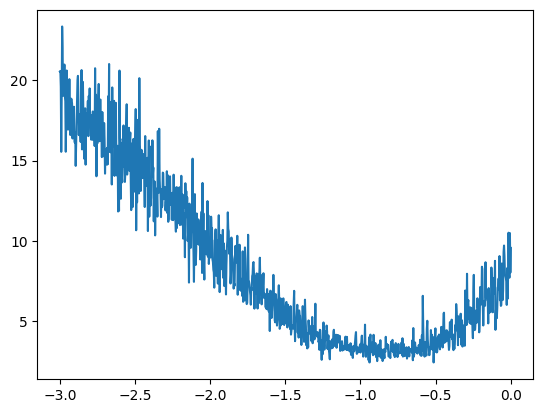

In [45]:
plt.plot(lri, lossi)

In [ ]:
# training split, dev/validation split, test split
# 80%, 10%, 10%; optimization of the model, hyperparameter tuning, evaluation metric. 

In [57]:
# build the dataset

def build_dataset(words):    
    block_size = 3  # context length: how many characters do we take to predict next?
    X, Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix]    # shift one charater to the left and append the new character

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, X.dtype, Y.shape, Y.dtype)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.int64 torch.Size([182580]) torch.int64
torch.Size([22767, 3]) torch.int64 torch.Size([22767]) torch.int64
torch.Size([22799, 3]) torch.int64 torch.Size([22799]) torch.int64


In [56]:
print(len(words), n1, n2, n1 - n2, len(words) - n2)

32033 25626 28829 -3203 3204


In [63]:
lri = []
lossi = []
for i in range(10000):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32, ))

    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])       #more efficient and numerically stable than the above naive implementation
    #print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update after track stats
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

print(loss.item())


2.1665101051330566


In [65]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

2.3776509761810303


In [64]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(loss.item())      # showing that the tr and dev loss are close, meaning that the model is not overfitting.

2.3793225288391113


In [87]:
# scaling up the size of neural network to get a better performance 
print(X.shape, Y.shape)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)        # each character gets mapped to a 2-dimensional vector; because scaling up the hidden layer does not really help (after checking), we can increase the dimension of the character embedding to get a better performance.
W1 = torch.randn((30, 200), generator=g)   # 6 is the number of input features, 100 is the number of output features
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
#print([p.shape for p in parameters])
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

# lre = torch.linspace(-3, 0, 1000)
# lrs = 10**lre
# lrs

torch.Size([228146, 3]) torch.Size([228146])
11897


In [88]:
lri = []
lossi = []
stepi = []

In [ ]:
for i in range(200000):
    #minibatch construct
    ix = torch.randint(0, X.shape[0], (32, ))

    # forward pass
    emb = C[X[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])       
    #print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update after track stats
    #lr = 0.01
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #update
    # lr = lrs[i]
    # for p in parameters:
    #     p.data += -lr * p.grad         

    # track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

2.031693458557129


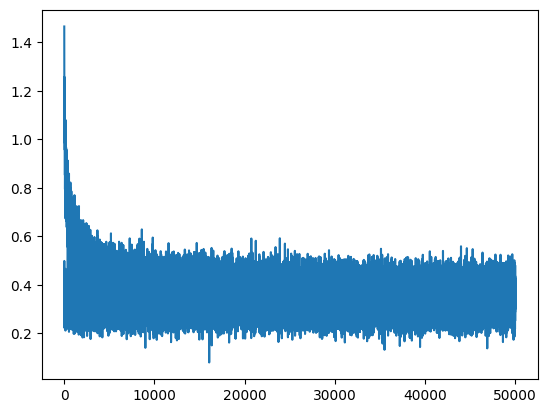

In [96]:
plt.plot(stepi, lossi)

In [97]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(loss.item())      # showing that the tr and dev loss are close, meaning that the model is not overfitting.

2.180051803588867
2.1757161617279053


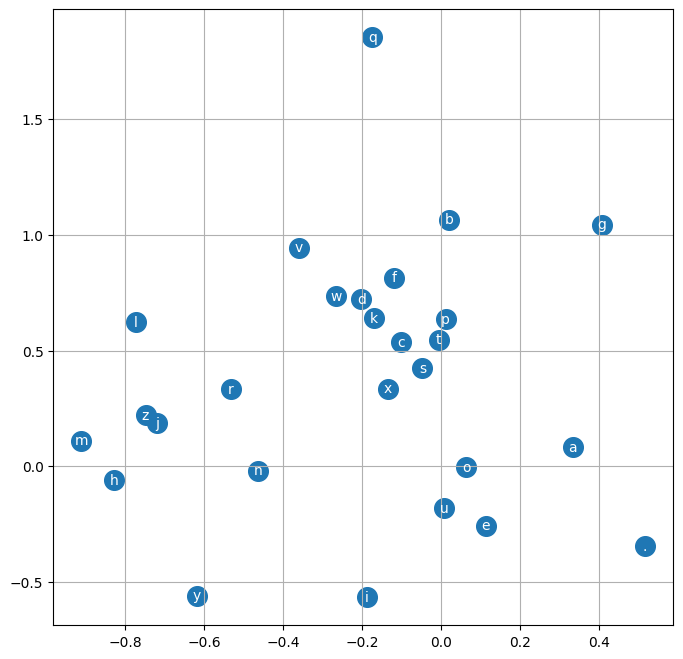

In [83]:
plt.figure(figsize=(8,8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [107]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    #print(out)
    print(''.join(itos[i] for i in out))        # this is more better than the previous names generated by previos lecture.

carmah.
amelle.
khirgree.
taty.
sacarsie.
mahnen.
amerynci.
aqui.
nellara.
chaiiv.
kaleig.
hham.
jore.
quint.
shous.
alvie.
quin.
troudiarysi.
jacee.
ivuan.


In [ ]:
# Homework 1: Tiny up the notebook to be py scrips
# Homework 2: Explain why the generated names are better than the previous lecture.